Lets Read Data for Analysis

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [ ]:
pip install plotly

In [ ]:
import plotly.express as px

In [ ]:
import os

In [ ]:
os.listdir(r"F:\Python Practice\Data Analyst Project\Developed Projects\Uber\Datasets")

In [ ]:
folder_path = "F:\\Python Practice\\Data Analyst Project\\Developed Projects\\Uber\\Datasets\\"
uber_15 = pd.read_csv(folder_path + "uber-raw-data-janjune-15_sample.csv")

In [ ]:
uber_15

In [ ]:
type(uber_15)

Lets Perfrom Data pre-Processing/Data Clean

In [ ]:
uber_15.shape

for below code ---> return all records, True means duplicate present of that record

In [ ]:
uber_15.duplicated()

In [ ]:
uber_15[uber_15.duplicated(keep=False)].sort_values(by = uber_15.columns.tolist())

In [ ]:
uber_15.drop_duplicates(inplace = True)

In [ ]:
uber_15.shape

In [ ]:
print(uber_15)

In [ ]:
uber_15.dtypes

Which month have max. Uber pickups in Newyork city?

In [ ]:
#uber_15['Pickup_date'].dtypes()
uber_15['Pickup_date'] = pd.to_datetime(uber_15['Pickup_date'], errors='coerce')
uber_15['month_name']  = uber_15['Pickup_date'].dt.month_name()
uber_15['week_day']    = uber_15['Pickup_date'].dt.day_name()
uber_15['day']         = uber_15['Pickup_date'].dt.day
uber_15['hour']        = uber_15['Pickup_date'].dt.hour
uber_15['minute']      = uber_15['Pickup_date'].dt.minute

In [ ]:
uber_15.head(15)

In [ ]:
pivot = pd.crosstab(index=uber_15['month_name'], columns =uber_15['week_day'])

In [ ]:
pivot

In [ ]:
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
weeks_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]


In [ ]:
pivot_sorted = pivot.reindex(index=months_order).reindex(columns=weeks_order).dropna()

In [ ]:
fig = px.bar(pivot_sorted,
      x = pivot_sorted.index,
      y = pivot_sorted.columns,
      barmode = "group",
      title = "Uber Pickups by Month and Weekday")

In [ ]:
fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "Number of Pickups",
    legend_title = "Weekday"
)

Lets Find out Hourly Rush in Newyork city on all days

In [88]:
uber_15.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month_name', 'week_day', 'day', 'hour', 'minute'],
      dtype='object')

In [93]:
hourly_rush = uber_15.groupby(['week_day','hour'], as_index=False).size()

In [94]:
hourly_rush

,week_day,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,897
165,Wednesday,21,949
166,Wednesday,22,900


In [96]:
hourly_rush.sort_values(['week_day','hour'])

,week_day,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,897
165,Wednesday,21,949
166,Wednesday,22,900


In [97]:
hourly_rush["week_day"]=pd.Categorical(hourly_rush["week_day"], categories = weeks_order, ordered = True)

In [98]:
hourly_rush = hourly_rush.sort_values(['week_day','hour'])

In [99]:
hourly_rush

,week_day,hour,size
24,Monday,0,339
25,Monday,1,178
26,Monday,2,109
27,Monday,3,100
28,Monday,4,139
...,...,...,...
91,Sunday,19,711
92,Sunday,20,697
93,Sunday,21,615
94,Sunday,22,658


In [102]:
hourly_fig = px.line(hourly_rush,
       x="hour",
       y="size",
       color = "week_day",
       markers=True,
       title="Hourly Uber Rush By Days")

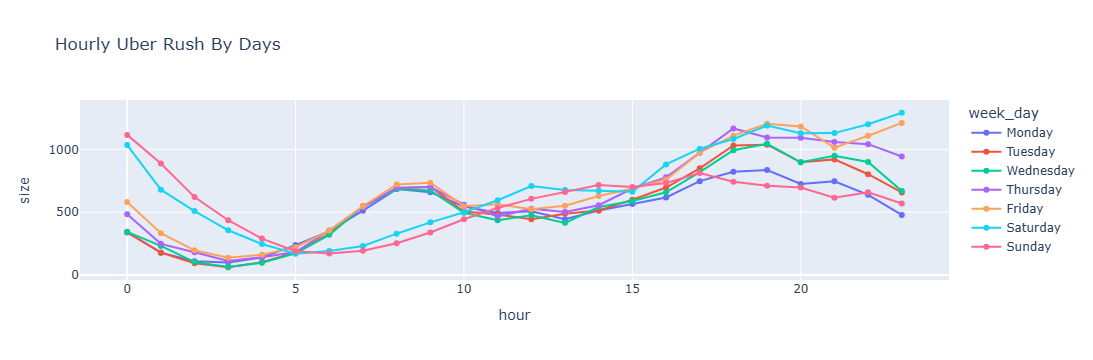

In [103]:
hourly_fig

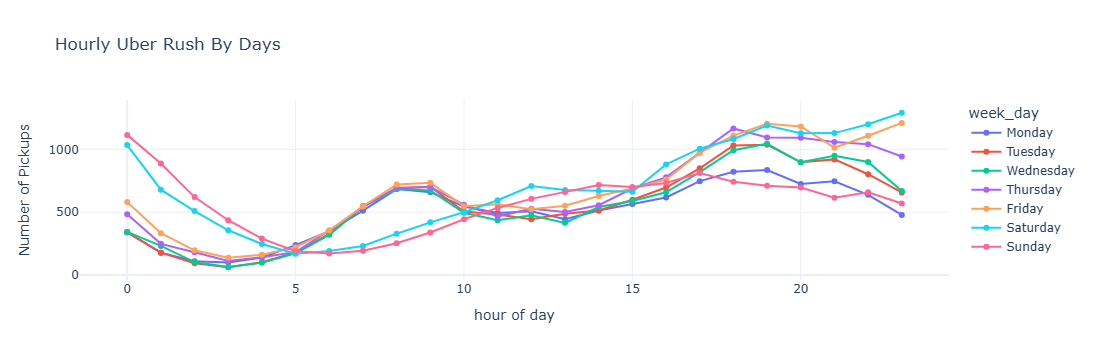

In [107]:
hourly_fig.update_layout(
    xaxis_title = "hour of day",
    yaxis_title = "Number of Pickups",
    legend_title = "week_day",
    template = "plotly_white"
)

Pareto Analysis : The 80-20 rule

In [108]:
uber_15.head(1)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month_name,week_day,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43


In [110]:
base_count = uber_15['Dispatching_base_num'].value_counts()

In [111]:
base_count

Dispatching_base_num
B02764    40267
B02682    24460
B02617    14496
B02598    10644
B02765     8120
B02512     1757
B02835      193
B02836        9
Name: count, dtype: int64

In [116]:
(base_count/base_count.sum()).cumsum()

Dispatching_base_num
B02764    0.402888
B02682    0.647620
B02617    0.792658
B02598    0.899156
B02765    0.980399
B02512    0.997979
B02835    0.999910
B02836    1.000000
Name: count, dtype: float64

In [117]:
base_df = base_count.reset_index()

In [118]:
base_df

,Dispatching_base_num,count
0,B02764,40267
1,B02682,24460
2,B02617,14496
3,B02598,10644
4,B02765,8120
5,B02512,1757
6,B02835,193
7,B02836,9


In [120]:
base_df.columns = ["Base","Trips"]

In [121]:
base_df

,Base,Trips
0,B02764,40267
1,B02682,24460
2,B02617,14496
3,B02598,10644
4,B02765,8120
5,B02512,1757
6,B02835,193
7,B02836,9


In [122]:
base_df["Trip_Percentage"] = base_df["Trips"]/base_df["Trips"].sum()
base_df

,Base,Trips,Trip_Percentage
0,B02764,40267,0.402888
1,B02682,24460,0.244732
2,B02617,14496,0.145038
3,B02598,10644,0.106498
4,B02765,8120,0.081244
5,B02512,1757,0.017579
6,B02835,193,0.001931
7,B02836,9,0.000090


In [123]:
base_df["Cumulative_Percentage"] = base_df["Trip_Percentage"].cumsum()

In [144]:
base_df

,Base,Trips,Trip_Percentage,Cumulative_Percentage
0,B02764,40267,0.402888,0.402888
1,B02682,24460,0.244732,0.647620
2,B02617,14496,0.145038,0.792658
3,B02598,10644,0.106498,0.899156
4,B02765,8120,0.081244,0.980399
5,B02512,1757,0.017579,0.997979
6,B02835,193,0.001931,0.999910
7,B02836,9,0.000090,1.000000


In [145]:
import plotly.graph_objs as go

In [147]:
pareto = go.Figure(
    data=[
        go.Bar(
            x=base_df["Base"],
            y=base_df["Trips"],
            name="Trips"
        ),
        go.Scatter(
            x=base_df["Base"],
            y=base_df["Cumulative_Percentage"],
            name="Cumulative %",
            mode="lines+markers",
            yaxis="y2"
        )
    ]
)

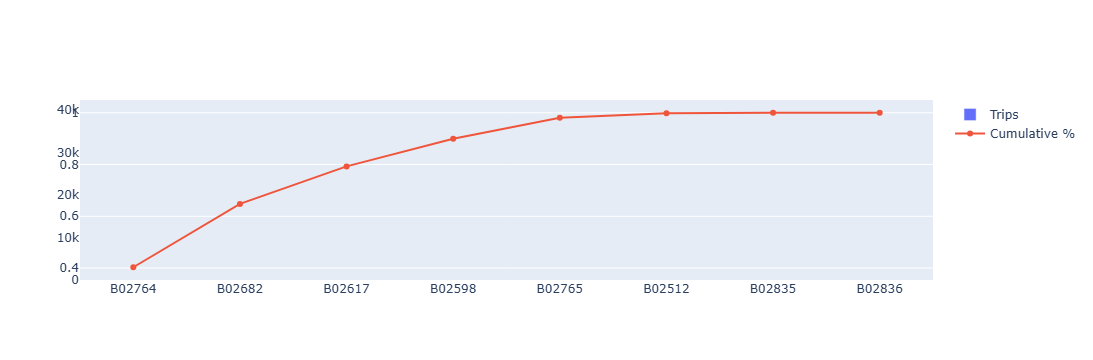

In [148]:
pareto

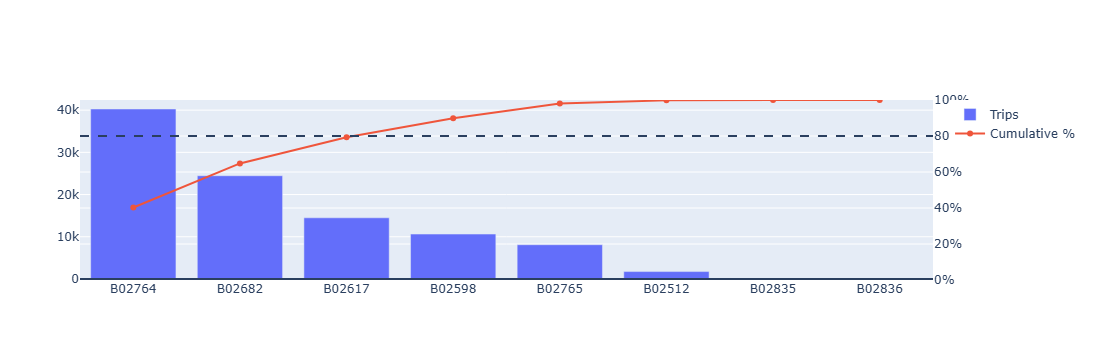

In [151]:
pareto.update_layout(yaxis2 = dict(overlaying = 'y', side ="right", tickformat = ".0%", range=[0,1]))
pareto.add_hline(y=0.8, yref ="y2", line_dash = "dash")

Airport Demand Analysis

In [153]:
uber_15 ["locationID"].unique()

array([237, 231, 161, 107, 140,  87, 125,  68, 163, 235, 112, 233, 262,
       132, 141, 170, 226,  42,  48, 158, 148, 186, 246,  25, 164,  97,
       138,  76, 143, 200, 238, 239, 144, 232, 162, 236, 113, 229,  15,
         4,  40,  49, 106, 100,  79, 114, 155, 165, 149, 197,  74, 211,
       119,  88, 142, 249, 234, 263,  35,  22, 228, 181, 137, 255, 210,
        72,  41,  36, 230, 209, 123,  37,  13,  50, 225,  45,  28, 256,
        66,  65,  61, 224,  17,  82,  70, 151,  56, 157,   7, 223,  11,
        85,  43, 166,  90, 188, 227, 192,  33, 145, 261,  52, 258,  24,
        14, 135,  80, 134,  95, 102, 174, 216, 193, 241,  18, 185, 259,
       260, 130, 215,  75, 220, 179, 121, 212,  62, 160,  92, 116, 243,
       247, 146, 244, 248, 257, 178,  26, 133, 214, 124, 198,  73,  39,
        78, 129,  89, 128,  71, 171, 180,  10, 175, 126, 203,  83, 219,
        69, 196, 190, 189,  63, 150, 156, 213,   3, 183,  53,  91,  77,
       250, 168, 202, 205,  54, 177, 152, 195, 159,  86, 242,  2

In [202]:
airports_ids = [1,132,128]

In [203]:
airport_df=uber_15[uber_15["locationID"].isin(airports_ids)]

In [204]:
airport_df

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month_name,week_day,day,hour,minute
15,B02617,2015-02-20 17:25:18,B02617,132,February,Friday,20,17,25
192,B02512,2015-03-04 05:54:00,B02682,132,March,Wednesday,4,5,54
327,B02598,2015-06-16 15:28:00,B02598,132,June,Tuesday,16,15,28
451,B02682,2015-01-19 23:27:21,B02682,132,January,Monday,19,23,27
490,B02764,2015-05-04 19:43:00,B01998,132,May,Monday,4,19,43
...,...,...,...,...,...,...,...,...,...
99681,B02598,2015-04-28 17:18:00,B02764,132,April,Tuesday,28,17,18
99761,B02765,2015-05-20 12:33:00,B02788,132,May,Wednesday,20,12,33
99884,B02765,2015-04-28 00:45:00,B02769,132,April,Tuesday,28,0,45
99898,B02682,2015-05-29 00:11:00,B02682,132,May,Friday,29,0,11


In [208]:
airport_map ={
    1:"EWR",
    132:"JFK",
    128:"LGA",
}    


In [209]:
###airport_df["airport_name"] = airport_df["locationID"].map(airport_map)
airport_df.loc[:, "airport_name"] = airport_df["locationID"].map(airport_map)


In [210]:
airport_name

15       JFK
192      JFK
327      JFK
451      JFK
490      JFK
        ... 
99681    JFK
99761    JFK
99884    JFK
99898    JFK
99953    JFK
Name: locationID, Length: 1958, dtype: object

In [211]:
airport_df

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month_name,week_day,day,hour,minute,airport_name
15,B02617,2015-02-20 17:25:18,B02617,132,February,Friday,20,17,25,JFK
192,B02512,2015-03-04 05:54:00,B02682,132,March,Wednesday,4,5,54,JFK
327,B02598,2015-06-16 15:28:00,B02598,132,June,Tuesday,16,15,28,JFK
451,B02682,2015-01-19 23:27:21,B02682,132,January,Monday,19,23,27,JFK
490,B02764,2015-05-04 19:43:00,B01998,132,May,Monday,4,19,43,JFK
...,...,...,...,...,...,...,...,...,...,...
99681,B02598,2015-04-28 17:18:00,B02764,132,April,Tuesday,28,17,18,JFK
99761,B02765,2015-05-20 12:33:00,B02788,132,May,Wednesday,20,12,33,JFK
99884,B02765,2015-04-28 00:45:00,B02769,132,April,Tuesday,28,0,45,JFK
99898,B02682,2015-05-29 00:11:00,B02682,132,May,Friday,29,0,11,JFK


In [212]:
airport_df.columns


Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month_name', 'week_day', 'day', 'hour', 'minute',
       'airport_name'],
      dtype='object')

In [213]:
airport_hourly = airport_df.groupby(['airport_name','hour']).size().reset_index(name = "trips")

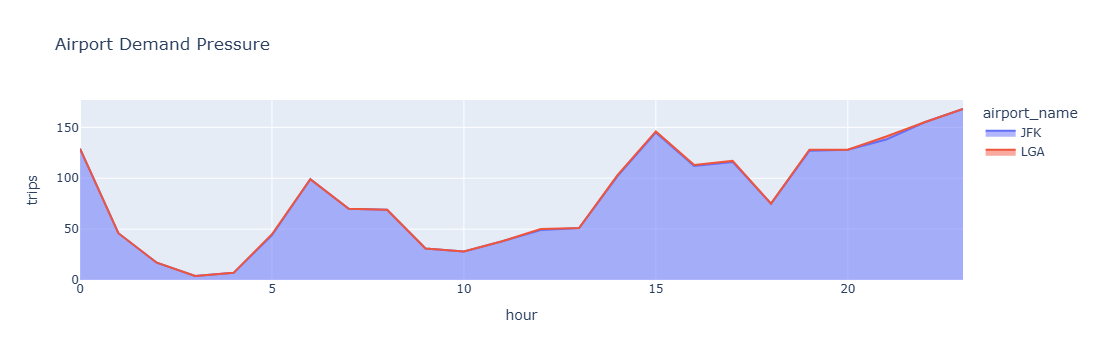

In [214]:
px.area(airport_hourly,
       x="hour",
       y="trips",
       color="airport_name",
       title = "Airport Demand Pressure")

In [234]:
files = os.listdir("F:\\Python Practice\\Data Analyst Project\\Developed Projects\\Uber\\Datasets")
files

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [249]:
final = pd.DataFrame()
file_path = r"F:\Python Practice\Data Analyst Project\Developed Projects\Uber\Datasets"
for file in files:
    print(file_path+file)
    current_df = pd.read_csv(file_path+"/"+file)
    final = pd.concat([current_df,final])
    
    

F:\Python Practice\Data Analyst Project\Developed Projects\Uber\Datasetsother-American_B01362.csv
F:\Python Practice\Data Analyst Project\Developed Projects\Uber\Datasetsother-Carmel_B00256.csv


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x96 in position 56424: invalid start byte

In [250]:
final.shape

(91712, 6)

In [251]:
final.duplicated().sum()

np.int64(588)

In [254]:
final.drop_duplicates(inplace = True)

In [257]:
final.head()

,DATE,TIME,PICK UP ADDRESS,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/1/2014,12:00:00 AM,"874 E 139th St Mott Haven, BX",NaN,NaN,NaN
1,7/1/2014,12:01:00 AM,"628 E 141st St Mott Haven, BX",NaN,NaN,NaN
2,7/1/2014,12:01:00 AM,"601 E 156th St South Bronx, BX",NaN,NaN,NaN
3,7/1/2014,12:01:00 AM,"708 E 138th St Mott Haven, BX",NaN,NaN,NaN
4,7/1/2014,12:02:00 AM,"700 E 140th St Mott Haven, BX",NaN,NaN,NaN


In [ ]:
Data Loading : CSV vs JSON vs Database vs Big Data

In [259]:
final.to_csv(r"F:\Python Practice\Data Analyst Project\Developed Projects\Uber\Datasets\data_csv.csv", index = False)

In [260]:
final.to_json(r"F:\Python Practice\Data Analyst Project\Developed Projects\Uber\Datasets\data_json.json", index = False)

In [261]:

pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [263]:
engine = create_engine("sqlite:///F:/Python Practice/Data Analyst Project/Developed Projects/Uber/Datasets/db.sqlite")

final.to_sql("Trips", con=engine, if_exists="append", index=False)

91124

Hourly Rush via Animated Spatial Analysis

In [264]:
final.dtypes

DATE                object
TIME                object
PICK UP ADDRESS     object
Unnamed: 3         float64
Unnamed: 4         float64
Unnamed: 5         float64
dtype: object

In [270]:
final["Date/Time"] = final["DATE"].astype(str) + " " + final["TIME"].astype(str)

In [271]:
final


,DATE,TIME,PICK UP ADDRESS,Unnamed: 3,Unnamed: 4,Unnamed: 5,Date/Time
0,7/1/2014,12:00:00 AM,"874 E 139th St Mott Haven, BX",NaN,NaN,NaN,7/1/2014 12:00:00 AM
1,7/1/2014,12:01:00 AM,"628 E 141st St Mott Haven, BX",NaN,NaN,NaN,7/1/2014 12:01:00 AM
2,7/1/2014,12:01:00 AM,"601 E 156th St South Bronx, BX",NaN,NaN,NaN,7/1/2014 12:01:00 AM
3,7/1/2014,12:01:00 AM,"708 E 138th St Mott Haven, BX",NaN,NaN,NaN,7/1/2014 12:01:00 AM
4,7/1/2014,12:02:00 AM,"700 E 140th St Mott Haven, BX",NaN,NaN,NaN,7/1/2014 12:02:00 AM
...,...,...,...,...,...,...,...
91707,9/30/2014,11:47:00 PM,"593 Oak Ter Mott Haven, BX",NaN,NaN,NaN,9/30/2014 11:47:00 PM
91708,9/30/2014,11:48:00 PM,"645 Westchester Ave South Bronx, BX",NaN,NaN,NaN,9/30/2014 11:48:00 PM
91709,9/30/2014,11:51:00 PM,"625 Tinton Ave South Bronx, BX",NaN,NaN,NaN,9/30/2014 11:51:00 PM
91710,9/30/2014,11:54:00 PM,"350 Saint Anns Ave Mott Haven, BX",NaN,NaN,NaN,9/30/2014 11:54:00 PM


In [275]:
final['Date/Time'] = pd.to_datetime(final["Date/Time"],'DD/MM/YYYY')
final

,DATE,TIME,PICK UP ADDRESS,Unnamed: 3,Unnamed: 4,Unnamed: 5,Date/Time
0,7/1/2014,12:00:00 AM,"874 E 139th St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:00:00
1,7/1/2014,12:01:00 AM,"628 E 141st St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:01:00
2,7/1/2014,12:01:00 AM,"601 E 156th St South Bronx, BX",NaN,NaN,NaN,2014-07-01 00:01:00
3,7/1/2014,12:01:00 AM,"708 E 138th St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:01:00
4,7/1/2014,12:02:00 AM,"700 E 140th St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:02:00
...,...,...,...,...,...,...,...
91707,9/30/2014,11:47:00 PM,"593 Oak Ter Mott Haven, BX",NaN,NaN,NaN,2014-09-30 23:47:00
91708,9/30/2014,11:48:00 PM,"645 Westchester Ave South Bronx, BX",NaN,NaN,NaN,2014-09-30 23:48:00
91709,9/30/2014,11:51:00 PM,"625 Tinton Ave South Bronx, BX",NaN,NaN,NaN,2014-09-30 23:51:00
91710,9/30/2014,11:54:00 PM,"350 Saint Anns Ave Mott Haven, BX",NaN,NaN,NaN,2014-09-30 23:54:00


In [276]:
final['hour']=final["Date/Time"].dt.hour

In [277]:
final

,DATE,TIME,PICK UP ADDRESS,Unnamed: 3,Unnamed: 4,Unnamed: 5,Date/Time,hour
0,7/1/2014,12:00:00 AM,"874 E 139th St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:00:00,0
1,7/1/2014,12:01:00 AM,"628 E 141st St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:01:00,0
2,7/1/2014,12:01:00 AM,"601 E 156th St South Bronx, BX",NaN,NaN,NaN,2014-07-01 00:01:00,0
3,7/1/2014,12:01:00 AM,"708 E 138th St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:01:00,0
4,7/1/2014,12:02:00 AM,"700 E 140th St Mott Haven, BX",NaN,NaN,NaN,2014-07-01 00:02:00,0
...,...,...,...,...,...,...,...,...
91707,9/30/2014,11:47:00 PM,"593 Oak Ter Mott Haven, BX",NaN,NaN,NaN,2014-09-30 23:47:00,23
91708,9/30/2014,11:48:00 PM,"645 Westchester Ave South Bronx, BX",NaN,NaN,NaN,2014-09-30 23:48:00,23
91709,9/30/2014,11:51:00 PM,"625 Tinton Ave South Bronx, BX",NaN,NaN,NaN,2014-09-30 23:51:00,23
91710,9/30/2014,11:54:00 PM,"350 Saint Anns Ave Mott Haven, BX",NaN,NaN,NaN,2014-09-30 23:54:00,23


In [282]:
pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


In [284]:

import folium

from folium.plugins import HeatMapWithTime

In [300]:
mp = folium.Map(
    location =[40.7128,-74.060],
    zoom_start = 11,
    tiles = "cartodbpositron",
)

In [301]:
mp

In [305]:
a=HeatMapWithTime(final['hour'],
               radius = 9,
               auto_play = False,
               max_opacity = 0.8).add_to(mp)

In [306]:
a